In [1]:
import numpy as np
import pandas as pd
import pickle
import cv2

import skimage as ski
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.spatial import KDTree
from skimage.measure import label, regionprops


from neural_reconstruction.core.preprocessing import SkinAnalysisPipeline
from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.core.evaluation import (
    GraphPointExtractor,
    extract_graph_points,
    compute_average_hausdorff_distance,
    compute_point_min_distances,
)

In [5]:
BASE_DIR = Path('/home/pony/projects/ienf_q')
DATASET_DIR = BASE_DIR / 'data/datasets'
DATA_DIR    = BASE_DIR / 'nas/jia/data_0320'

# Auto-discover all sample IDs that have both CSV and pkl
SAMPLE_IDS = sorted(
    p.stem.removeprefix('dataset_')
    for p in DATASET_DIR.glob('dataset_*.csv')
    if not p.stem.endswith('_paths')
    and (DATASET_DIR / f"{p.stem}_paths.pkl").exists()
)


# Seed graph
SEGMENT_LENGTH = 3

# A* search
SEARCH_RADIUS        = 100
BBOX_PADDING         = 10


PATH_FINDING_BBOX_PADDING = 10
HAUSDORFF_INF_SENTINEL = 10**10
HAUSDORFF_IN_LABEL_TOLERANCE = 10

BRIGHT_THRESHOLD = 128  # for frac_bright feature

print(f"Found {len(SAMPLE_IDS)} sample(s): {SAMPLE_IDS}")

Found 17 sample(s): ['S1140-2_a', 'S1140-2_b', 'S1585-2_a', 'S1585-2_b', 'S1616-2_a', 'S222-2_a', 'S222-2_b', 'S226-2_a', 'S226-2_b', 'S236-2_a', 'S236-2_b', 'S341-2_a', 'S341-2_b', 'S487-2_a', 'S487-2_b', 'S558-2_a', 'S558-2_b']


In [6]:
def extract_path_features(path, orig_img, threshold=128):
    """Extract image-based features along an A* path."""
    pts = np.array(path)
    intensities = orig_img[pts[:, 0], pts[:, 1]].astype(np.float32)

    # Max perpendicular deviation from the straight line connecting endpoints
    start, end = pts[0].astype(float), pts[-1].astype(float)
    line_vec = end - start
    line_len = np.linalg.norm(line_vec)
    if line_len > 0:
        max_deviation = float(np.max(np.abs(np.cross(line_vec / line_len, pts - start))))
    else:
        max_deviation = 0.0

    return {
        # Intensity statistics
        'mean_intensity':     float(np.mean(intensities)),
        'max_intensity':      float(np.max(intensities)),
        'min_intensity':      float(np.min(intensities)),
        'median_intensity':   float(np.median(intensities)),
        'std_intensity':      float(np.std(intensities)),
        'intensity_q25':      float(np.percentile(intensities, 25)),
        'intensity_q75':      float(np.percentile(intensities, 75)),
        'frac_bright':        float(np.mean(intensities > threshold)),
        # Endpoint intensity (are seeds on bright tissue?)
        'endpoint_intensity': float((intensities[0] + intensities[-1]) / 2),
        # Path shape
        'max_deviation':      max_deviation,
    }

def compute_path_hausdorff_sum(path: list, gt_kdtree: KDTree) -> float:
    """Sum of min distances from each path point to the nearest GT pixel."""
    path_pts = np.array(path)
    dists, _ = gt_kdtree.query(path_pts)
    return float(np.sum(dists))


def load_and_featurize(sample_id, dataset_dir, data_dir, threshold=128):
    """Load CSV + pkl + image, return feature DataFrame."""
    img_path = data_dir / sample_id / 'image.png'

    orig_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    orig_green = cv2.split(orig_bgr)[1]  # BGR → green channel (index 1)
    annotation_img = cv2.imread(
        str(data_dir / sample_id / "annotation.png"), cv2.IMREAD_GRAYSCALE
    )
    label_img = cv2.imread(str(data_dir / sample_id / "label.png"), cv2.IMREAD_GRAYSCALE)

    if annotation_img is None:
        raise FileNotFoundError(f"Cannot read annotation.png in {data_dir / sample_id}")
    if label_img is None:
        raise FileNotFoundError(f"Cannot read label.png in {data_dir / sample_id}")

    h, w = annotation_img.shape

    # Build full-image mask (no mask.png in this dataset)
    mask_path = data_dir / sample_id / "mask.png"
    epidermis_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
        
    orig_img = cv2.imread(str(img_path), cv2.IMREAD_COLOR_RGB)
    orig_img = np.array(orig_img)[:, :, 1]  # green channel
        
    sample_pipeline = SkinAnalysisPipeline()
    sample_pipeline.config.threshold.use_full_roi = False
    final_annotation, roi_image, roi_mask = sample_pipeline.run(
        annotation_img, epidermis_mask, orig_green
    )
    topology_builder = TopologyBuilder(segment_length=SEGMENT_LENGTH)
    seed_graph = topology_builder.build_seed_graph(final_annotation, roi_image)

    for u, v, data in seed_graph.edges(data=True):
        data["weight"] = 1e-5

    topology_points = np.array(list(seed_graph.nodes()))
    kdtree = KDTree(topology_points)

    # 必須與訓練資料完全一致：raw green channel + 指數 8
    cost_map = ((255 - roi_image.astype(np.float64)) / 255.0) ** 8

    seed_map = np.zeros_like(cost_map, dtype=np.uint8)
    for p in topology_points:
        seed_map[p[0], p[1]] = True

    binary = (final_annotation > 0).astype(np.uint8)
    comp_map = label(binary, connectivity=2)

    path_finder = PathFinder(cost_map=cost_map)

    path_lookup = path_finder.find_paths_from_seeds(
        topology_points=topology_points,
        kdtree=kdtree,
        search_radius=SEARCH_RADIUS,
        seed_map=seed_map,
        label_img=comp_map,
    )

    label_binary = label_img > 0
    all_samples = []
    gt_pixels = np.column_stack(np.where(label_img > 0))
    gt_kdtree = KDTree(gt_pixels)
    label_binary = label_img > 0

    gt_builder = TopologyBuilder(segment_length=SEGMENT_LENGTH)
    gt_graph   = gt_builder.build_seed_graph(label_img)
    extractor = GraphPointExtractor(remove_duplicates=True)
    gt_kdtree  = KDTree(extractor.extract_points(gt_graph, include_nodes=False, include_edge_paths=True))

    for (u, v), (path, cost) in path_lookup.items():
        path_pts = np.array(path)
        path_in_label = label_binary[path_pts[:, 0], path_pts[:, 1]]
        hausdorff_sum = compute_path_hausdorff_sum(path, gt_kdtree)
        if (
            not np.all(path_in_label)
            and hausdorff_sum > HAUSDORFF_IN_LABEL_TOLERANCE
        ):
            hausdorff_sum = HAUSDORFF_INF_SENTINEL

        distance = float(np.linalg.norm(np.array(u) - np.array(v)))
        pth_arr = np.array(path)
        # calculate path length as sum of Euclidean distances between consecutive points
        path_length = float(np.sum(np.linalg.norm(np.diff(pth_arr, axis=0), axis=1)))
        normalized_cost = float(cost / max(path_length, 1e-8))

        all_samples.append(
            {
                "pair_id": f"{sample_id}_{u[0]}_{u[1]}_{v[0]}_{v[1]}",
                "image_id": sample_id,
                "seed1_y": u[0],
                "seed1_x": u[1],
                "seed2_y": v[0],
                "seed2_x": v[1],
                "distance": distance,
                "path_length": path_length,
                "path_cost": cost,
                "normalized_cost": normalized_cost,
                "hausdorff_sum": hausdorff_sum,
                "path": path,
                "label": hausdorff_sum < HAUSDORFF_IN_LABEL_TOLERANCE,
                "tortuosity" : path_length / max(distance, 1e-8),
                **extract_path_features(path, roi_image, threshold)
            }
        )

    result = pd.DataFrame(all_samples)
    print(f"{sample_id}: {len(result)} samples  "
          f"(label=1: {result['label'].sum()}, label=0: {(result['label']==0).sum()})")
    return result


print('Functions defined')

Functions defined


In [7]:
all_dfs = [load_and_featurize(sid, DATASET_DIR, DATA_DIR, BRIGHT_THRESHOLD)
           for sid in SAMPLE_IDS]
full_df = pd.concat(all_dfs, ignore_index=True)

print(f"\nTotal: {len(full_df)} samples")
print(f"label=1: {full_df['label'].sum()}, label=0: {(full_df['label']==0).sum()}")

/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:104: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)
/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:104: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)
/tmp/ipykernel_699323/413367942.py:11: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  max_deviation = float(np.max(np.abs(np.cross(line_vec / line_len, pts - start))))


S1140-2_a: 7197 samples  (label=1: 825, label=0: 6372)
S1140-2_b: 7296 samples  (label=1: 1114, label=0: 6182)
S1585-2_a: 5021 samples  (label=1: 721, label=0: 4300)
S1585-2_b: 6545 samples  (label=1: 678, label=0: 5867)
S1616-2_a: 4482 samples  (label=1: 128, label=0: 4354)
S222-2_a: 10152 samples  (label=1: 63, label=0: 10089)
S222-2_b: 6028 samples  (label=1: 42, label=0: 5986)
S226-2_a: 4936 samples  (label=1: 112, label=0: 4824)
S226-2_b: 4526 samples  (label=1: 72, label=0: 4454)
S236-2_a: 12642 samples  (label=1: 217, label=0: 12425)
S236-2_b: 8475 samples  (label=1: 113, label=0: 8362)
S341-2_a: 11878 samples  (label=1: 274, label=0: 11604)
S341-2_b: 8247 samples  (label=1: 232, label=0: 8015)
S487-2_a: 17967 samples  (label=1: 440, label=0: 17527)
S487-2_b: 11605 samples  (label=1: 332, label=0: 11273)
S558-2_a: 5722 samples  (label=1: 194, label=0: 5528)
S558-2_b: 3066 samples  (label=1: 83, label=0: 2983)

Total: 135785 samples
label=1: 5640, label=0: 130145


In [47]:
# Cap sentinel hausdorff_sum values and set up regression target
HAUSDORFF_CAP = 500.0

full_df = full_df.copy()
full_df['target'] = full_df['hausdorff_sum'].clip(upper=HAUSDORFF_CAP)

print(f"Total samples: {len(full_df)}")
print(f"Target stats — min: {full_df['target'].min():.2f}, "
      f"max: {full_df['target'].max():.2f}, "
      f"mean: {full_df['target'].mean():.2f}, "
      f"median: {full_df['target'].median():.2f}")

Total samples: 135785
Target stats — min: 0.00, max: 500.00, mean: 413.68, median: 500.00


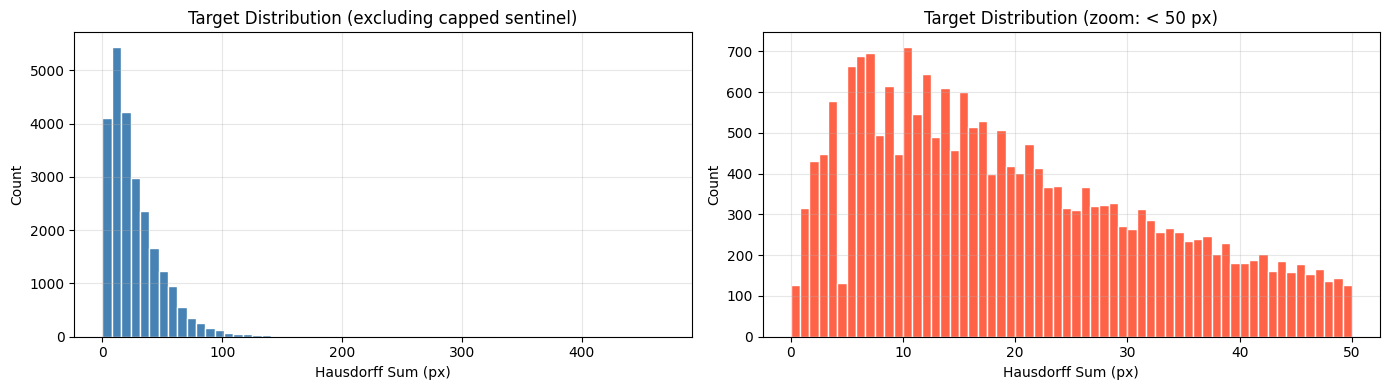

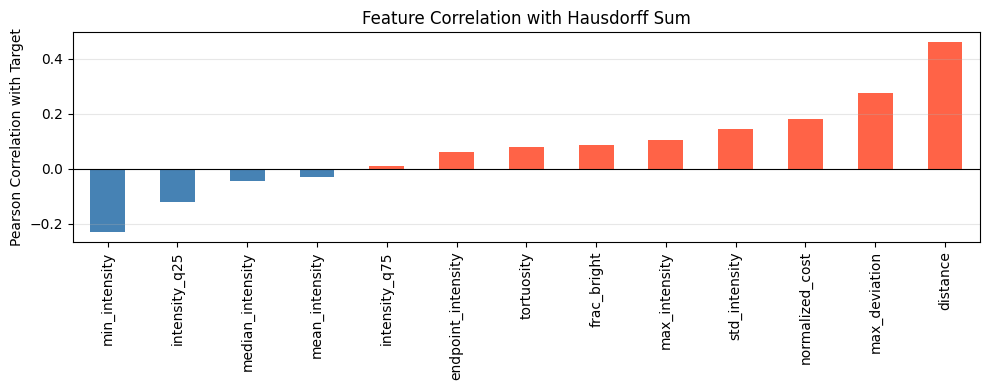

In [48]:
FEATURES = [
    'distance', 'normalized_cost', 'tortuosity',
    'mean_intensity', 'max_intensity', 'min_intensity', 'median_intensity',
    'std_intensity', 'intensity_q25', 'intensity_q75',
    'frac_bright', 'endpoint_intensity', 'max_deviation',
]

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(full_df['target'][full_df['target'] < HAUSDORFF_CAP], bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hausdorff Sum (px)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution (excluding capped sentinel)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(full_df['target'][full_df['target'] < 50], bins=60,
             color='tomato', edgecolor='white')
axes[1].set_xlabel('Hausdorff Sum (px)')
axes[1].set_ylabel('Count')
axes[1].set_title('Target Distribution (zoom: < 50 px)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature vs target correlations
corrs = full_df[FEATURES + ['target']].corr()['target'].drop('target').sort_values()
fig, ax = plt.subplots(figsize=(10, 4))
corrs.plot(kind='bar', ax=ax, color=['tomato' if v > 0 else 'steelblue' for v in corrs])
ax.set_ylabel('Pearson Correlation with Target')
ax.set_title('Feature Correlation with Hausdorff Sum')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [49]:
X = full_df[FEATURES].values
y = full_df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {len(X_train)}")
print(f"Test:  {len(X_test)}")
print(f"y_train — mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"y_test  — mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")

Train: 108628
Test:  27157
y_train — mean: 413.53, std: 182.98
y_test  — mean: 414.28, std: 182.33


## 6. XGBoost Regression Training

In [50]:
model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-rmse:179.23851
[50]	validation_0-rmse:141.20608
[100]	validation_0-rmse:137.22122
[150]	validation_0-rmse:135.26192
[200]	validation_0-rmse:133.58788
[250]	validation_0-rmse:132.22029
[300]	validation_0-rmse:131.02503
[350]	validation_0-rmse:130.06882
[400]	validation_0-rmse:129.18799
[450]	validation_0-rmse:128.60071
[500]	validation_0-rmse:127.98592
[550]	validation_0-rmse:127.50517
[600]	validation_0-rmse:127.09765
[650]	validation_0-rmse:126.59761
[700]	validation_0-rmse:126.14425
[750]	validation_0-rmse:125.76629
[800]	validation_0-rmse:125.42643
[850]	validation_0-rmse:125.15418
[900]	validation_0-rmse:124.90737
[950]	validation_0-rmse:124.60265
[999]	validation_0-rmse:124.42982

Best iteration: 999


## 7. Evaluation

In [51]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f} px")
print(f"RMSE: {rmse:.4f} px")
print(f"R²:   {r2:.4f}")

MAE:  74.0194 px
RMSE: 124.4298 px
R²:   0.5343


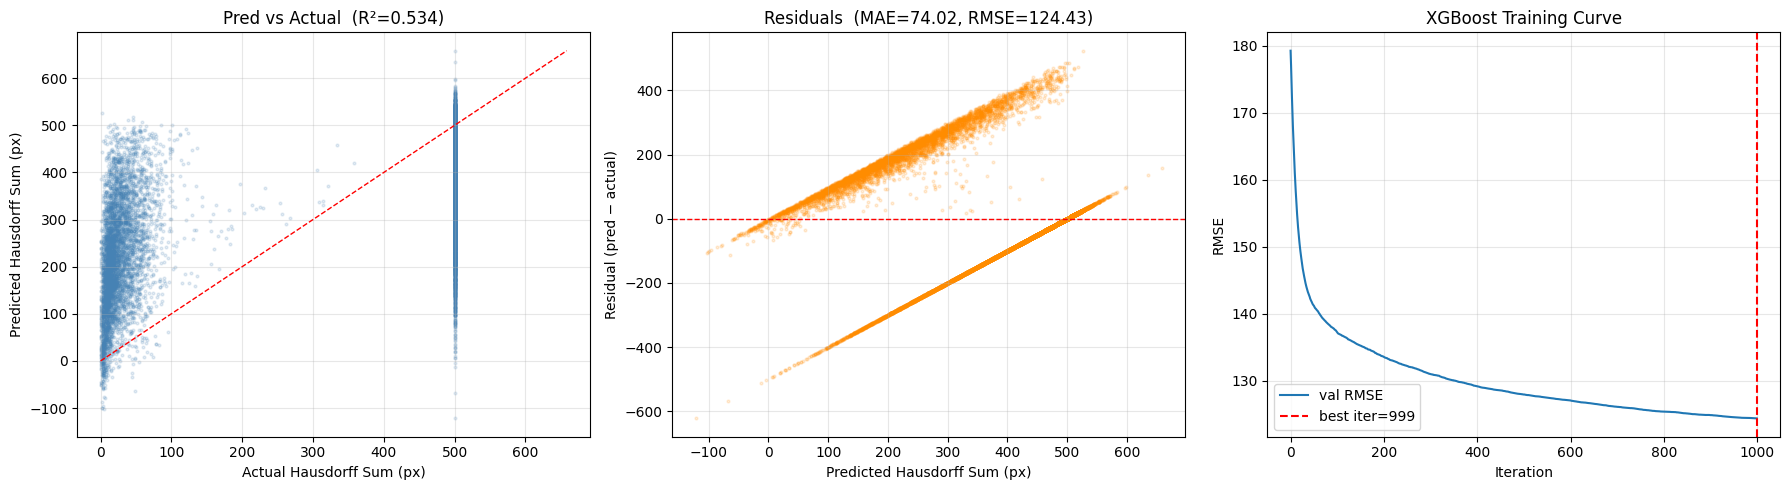

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pred vs Actual scatter
axes[0].scatter(y_test, y_pred, alpha=0.15, s=4, color='steelblue')
lim = max(y_test.max(), y_pred.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlabel('Actual Hausdorff Sum (px)')
axes[0].set_ylabel('Predicted Hausdorff Sum (px)')
axes[0].set_title(f'Pred vs Actual  (R²={r2:.3f})')
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_pred - y_test
axes[1].scatter(y_pred, residuals, alpha=0.15, s=4, color='darkorange')
axes[1].axhline(0, color='r', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted Hausdorff Sum (px)')
axes[1].set_ylabel('Residual (pred − actual)')
axes[1].set_title(f'Residuals  (MAE={mae:.2f}, RMSE={rmse:.2f})')
axes[1].grid(True, alpha=0.3)

# Training RMSE curve
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
axes[2].plot(range(epochs), results['validation_0']['rmse'], label='val RMSE')
axes[2].axvline(model.best_iteration, color='r', linestyle='--',
                label=f'best iter={model.best_iteration}')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('RMSE')
axes[2].set_title('XGBoost Training Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 特徵重要性

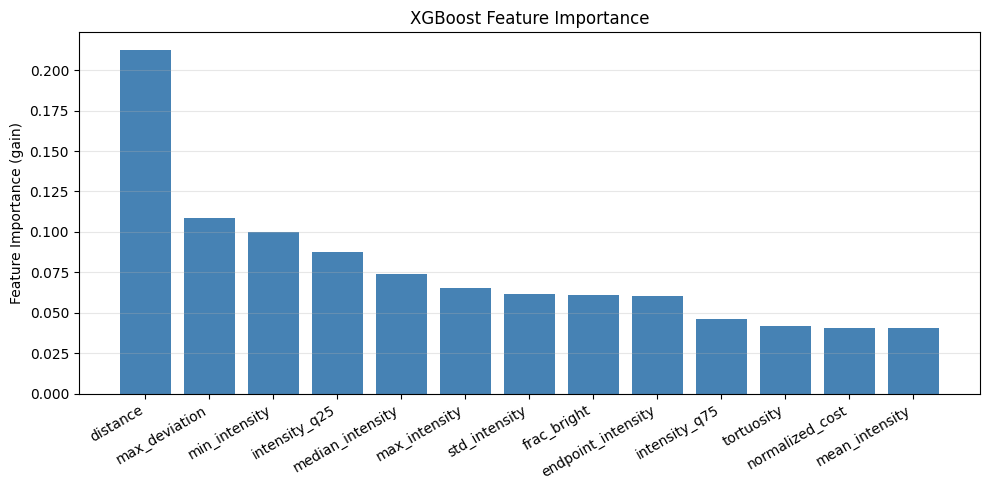

In [53]:
importances = model.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(FEATURES)), importances[order], color='steelblue')
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels([FEATURES[i] for i in order], rotation=30, ha='right')
ax.set_ylabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [54]:
import pickle as _pickle

model_pkl_path = DATASET_DIR / 'xgb_connection_weigher.pkl'
with open(model_pkl_path, 'wb') as f:
    _pickle.dump(model, f)
print(f"Model saved (pickle): {model_pkl_path}")

Model saved (pickle): /home/pony/projects/ienf_q/data/datasets/xgb_connection_weigher.pkl


## 9. Per-Sample Accuracy

In [55]:
model.save_model(str(DATASET_DIR / 'xgb_connection_filter.json'))

In [56]:
rows = []
for sid, df in zip(SAMPLE_IDS, all_dfs):
    df = df.copy()
    df['target'] = df['hausdorff_sum'].clip(upper=HAUSDORFF_CAP)
    X_s = scaler.transform(df[FEATURES].values)
    y_s = df['target'].values

    y_pred_s = model.predict(X_s)

    mae_s  = mean_absolute_error(y_s, y_pred_s)
    rmse_s = mean_squared_error(y_s, y_pred_s) ** 0.5
    r2_s   = r2_score(y_s, y_pred_s)

    rows.append({
        'sample_id': sid,
        'n_total':   len(y_s),
        'mae':       round(mae_s, 2),
        'rmse':      round(rmse_s, 2),
        'r2':        round(r2_s, 4),
    })

per_sample_df = pd.DataFrame(rows)
per_sample_df = per_sample_df.sort_values('mae', ascending=False).reset_index(drop=True)

print(per_sample_df.to_string(index=False))
print(f"\nMean MAE : {per_sample_df['mae'].mean():.2f}")
print(f"Mean RMSE: {per_sample_df['rmse'].mean():.2f}")
print(f"Mean R²  : {per_sample_df['r2'].mean():.4f}")

sample_id  n_total   mae   rmse      r2
 S341-2_b     8247 79.87 126.02  0.5668
 S341-2_a    11878 76.52 120.57  0.6141
 S558-2_a     5722 74.80 118.16  0.6070
 S226-2_b     4526 74.58 118.38  0.5676
 S487-2_b    11605 72.28 117.54  0.6829
 S487-2_a    17967 71.46 122.27  0.6437
 S226-2_a     4936 64.79 109.40  0.6375
 S236-2_a    12642 63.37 107.29  0.6356
S1585-2_a     5021 62.97 101.39  0.7481
 S558-2_b     3066 61.71 109.28  0.4368
S1585-2_b     6545 59.65  97.66  0.6995
S1616-2_a     4482 58.56 103.51  0.3569
S1140-2_a     7197 56.27  96.61  0.7525
 S222-2_a    10152 54.37  90.45 -0.4151
 S222-2_b     6028 51.35  92.15  0.2383
 S236-2_b     8475 48.66  86.94  0.5922
S1140-2_b     7296 48.11  85.42  0.8428

Mean MAE : 63.49
Mean RMSE: 106.06
Mean R²  : 0.5416


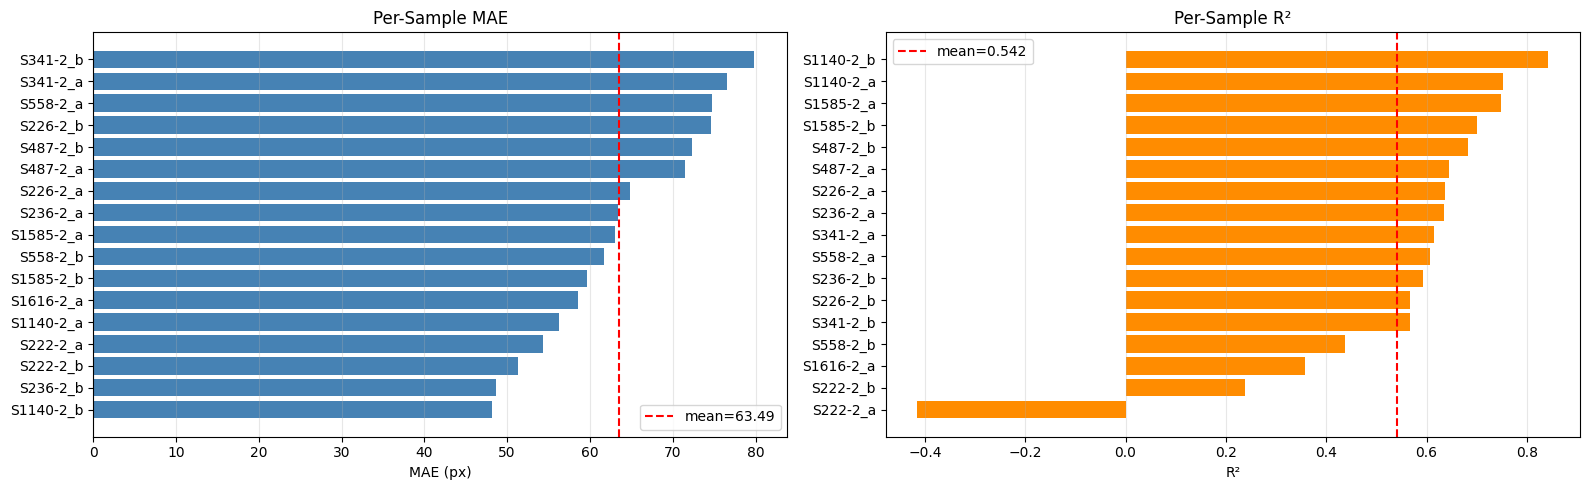

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sorted_mae = per_sample_df.sort_values('mae')
axes[0].barh(sorted_mae['sample_id'], sorted_mae['mae'], color='steelblue')
axes[0].axvline(per_sample_df['mae'].mean(), color='red', linestyle='--',
                label=f"mean={per_sample_df['mae'].mean():.2f}")
axes[0].set_xlabel('MAE (px)')
axes[0].set_title('Per-Sample MAE')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

sorted_r2 = per_sample_df.sort_values('r2')
axes[1].barh(sorted_r2['sample_id'], sorted_r2['r2'], color='darkorange')
axes[1].axvline(per_sample_df['r2'].mean(), color='red', linestyle='--',
                label=f"mean={per_sample_df['r2'].mean():.3f}")
axes[1].set_xlabel('R²')
axes[1].set_title('Per-Sample R²')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 10. 單張樣本視覺化

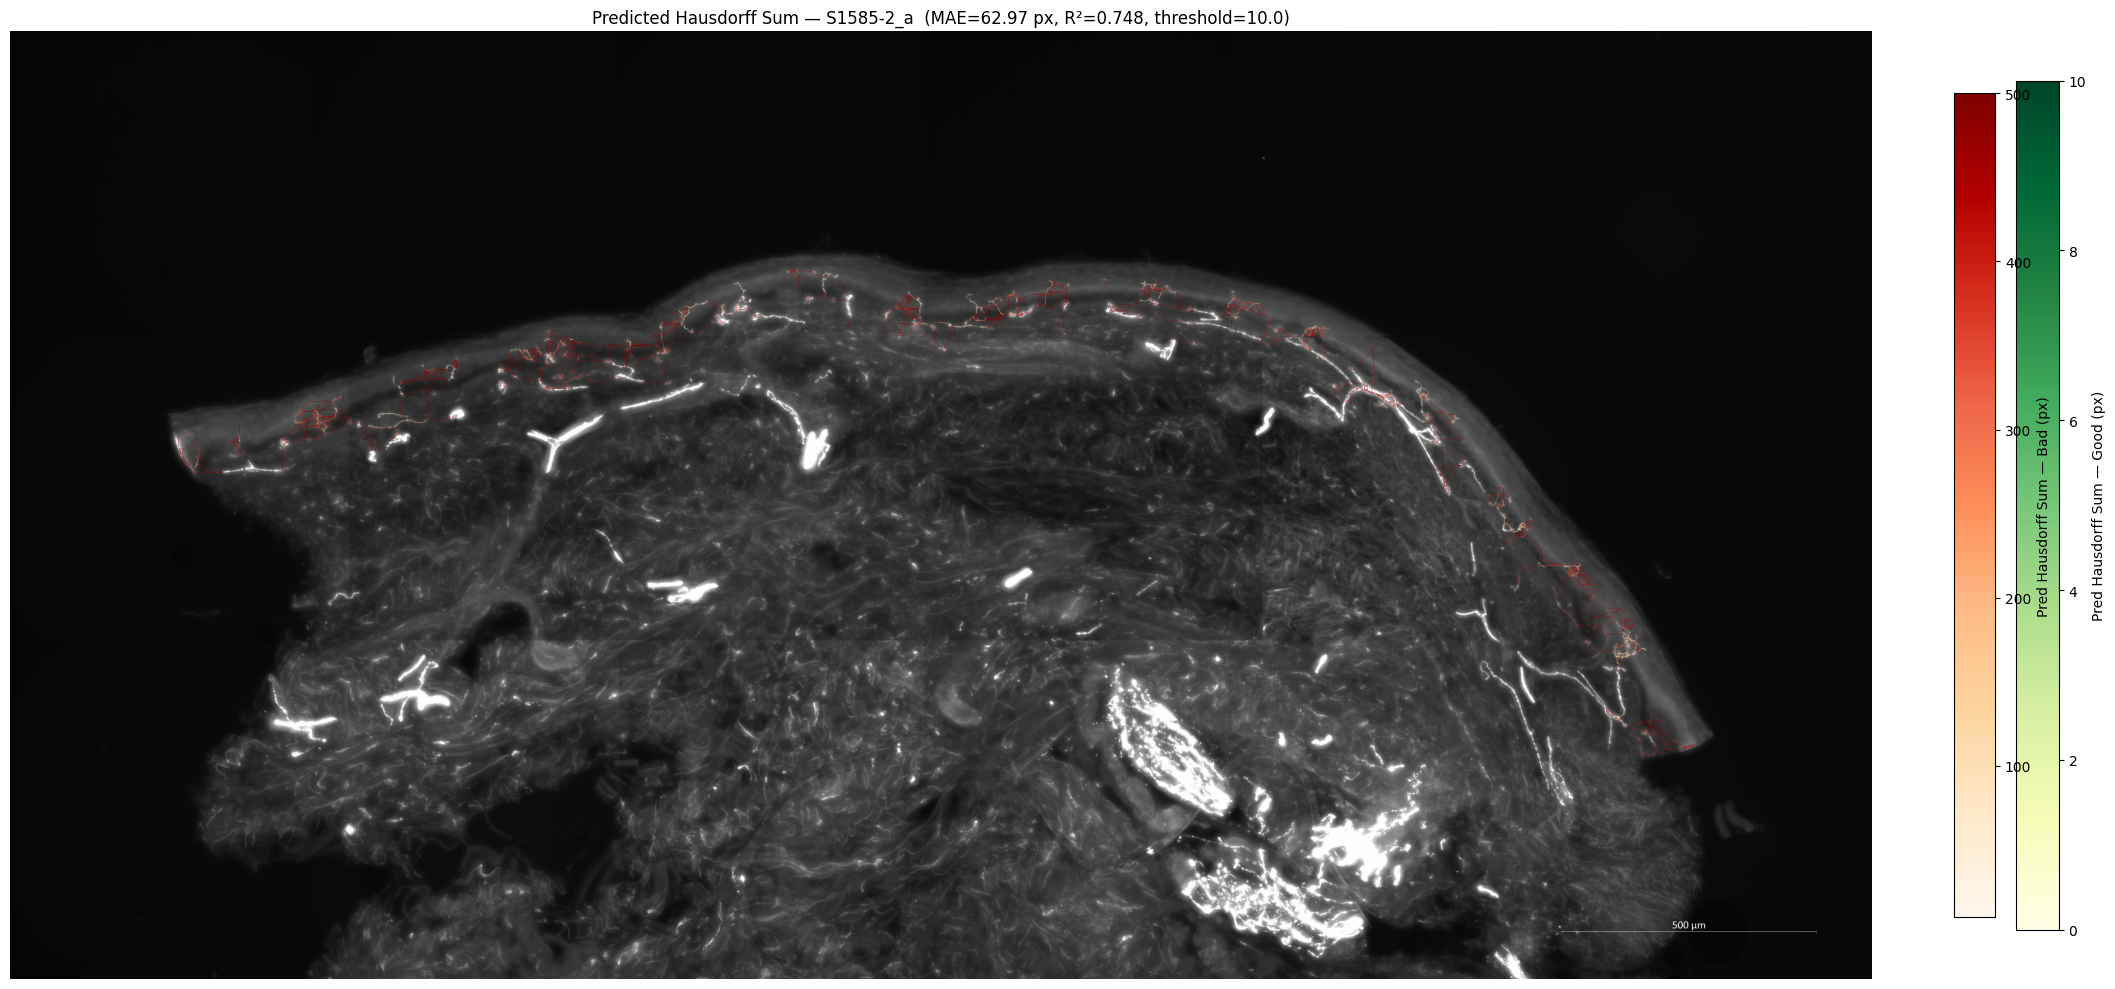

In [58]:

# ── Config ────────────────────────────────────────────────────────────────────
VIS_SAMPLE_ID  = "S1585-2_a"
PRED_THRESHOLD = 10.0   # treat predicted hausdorff_sum < threshold as "good"

vis_df = full_df[full_df['image_id'] == VIS_SAMPLE_ID].reset_index(drop=True)

img_path = DATA_DIR / VIS_SAMPLE_ID / 'image.png'
orig_bgr  = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
orig_green = cv2.split(orig_bgr)[1]

# ── Predict ───────────────────────────────────────────────────────────────────
X_vis    = scaler.transform(vis_df[FEATURES].values)
y_vis    = vis_df['target'].values
y_pred_v = model.predict(X_vis)

# ── Draw paths colored by predicted hausdorff_sum ─────────────────────────────
# Good (pred < threshold) → green gradient; Bad (pred >= threshold) → red
cmap_good = plt.cm.YlGn
cmap_bad  = plt.cm.OrRd
good_mask = y_pred_v < PRED_THRESHOLD
good_norm = plt.Normalize(vmin=0, vmax=PRED_THRESHOLD)
bad_norm  = plt.Normalize(vmin=PRED_THRESHOLD, vmax=HAUSDORFF_CAP)

canvas = cv2.cvtColor(orig_green, cv2.COLOR_GRAY2RGB).copy()

for i, (row_idx, row) in enumerate(vis_df.iterrows()):
    path = row['path']
    if path is None:
        continue
    pred_val = float(y_pred_v[i])
    if good_mask[i]:
        rgba = cmap_good(good_norm(pred_val))
    else:
        rgba = cmap_bad(bad_norm(min(pred_val, HAUSDORFF_CAP)))
    color = (int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))
    pts = np.array(path)
    canvas[pts[:, 0], pts[:, 1]] = color

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(22, 10))
ax.imshow(canvas)

sm_good = plt.cm.ScalarMappable(cmap=cmap_good, norm=good_norm)
sm_good.set_array([])
sm_bad  = plt.cm.ScalarMappable(cmap=cmap_bad,  norm=bad_norm)
sm_bad.set_array([])
plt.colorbar(sm_good, ax=ax, label='Pred Hausdorff Sum — Good (px)', fraction=0.02, pad=0.01)
plt.colorbar(sm_bad,  ax=ax, label='Pred Hausdorff Sum — Bad (px)',  fraction=0.02, pad=0.04)

mae_v = mean_absolute_error(y_vis, y_pred_v)
r2_v  = r2_score(y_vis, y_pred_v)
ax.set_title(f'Predicted Hausdorff Sum — {VIS_SAMPLE_ID}  '
             f'(MAE={mae_v:.2f} px, R²={r2_v:.3f}, threshold={PRED_THRESHOLD})')
ax.axis('off')
plt.tight_layout()
plt.show()


In [59]:
import joblib
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']